In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load the data
df = pd.read_csv('student_lifestyle_dataset..csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

print("\nStress Level Distribution:")
print(df['Stress_Level'].value_counts())

print("\nGender Distribution:")
print(df['Gender'].value_counts())

Dataset Shape: (2000, 9)

First few rows:
   Student_ID  Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  \
0           1                  6.9                            3.8   
1           2                  5.3                            3.5   
2           3                  5.1                            3.9   
3           4                  6.5                            2.1   
4           5                  8.1                            0.6   

   Sleep_Hours_Per_Day  Social_Hours_Per_Day  Physical_Activity_Hours_Per_Day  \
0                  8.7                   2.8                              1.8   
1                  8.0                   4.2                              3.0   
2                  9.2                   1.2                              4.6   
3                  7.2                   1.7                              6.5   
4                  6.5                   2.2                              6.6   

  Stress_Level  Gender  Grades  
0     Moderate    Male 

Q1: PRIORITY FACTORS FOR IMPROVING PERFORMANCE WHILE REDUCING STRESS

Correlation Analysis:
                                 Correlation_with_Grades  \
Sleep_Hours_Per_Day                            -0.004259   
Study_Hours_Per_Day                             0.734401   
Extracurricular_Hours_Per_Day                  -0.032073   
Social_Hours_Per_Day                           -0.085713   
Physical_Activity_Hours_Per_Day                -0.341148   

                                 Correlation_with_Stress  Combined_Score  
Sleep_Hours_Per_Day                            -0.298917        0.294658  
Study_Hours_Per_Day                             0.738843       -0.004442  
Extracurricular_Hours_Per_Day                  -0.006099       -0.025974  
Social_Hours_Per_Day                           -0.054702       -0.031011  
Physical_Activity_Hours_Per_Day                -0.205207       -0.135941  


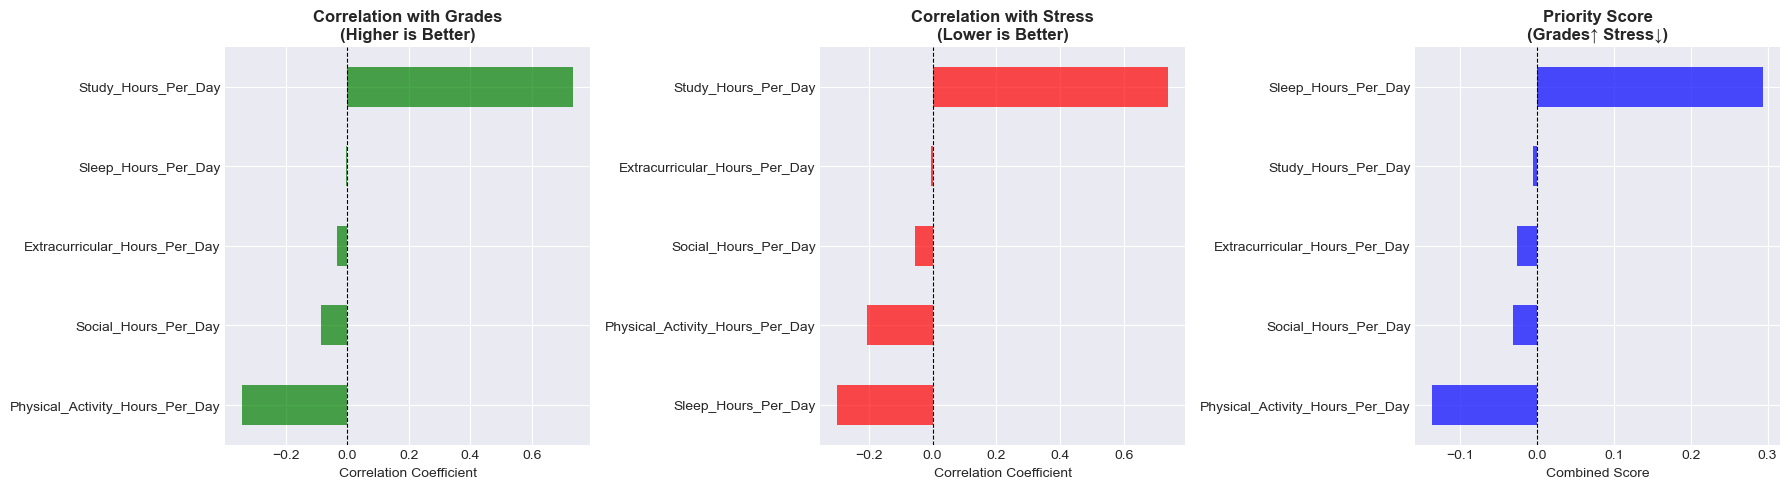


COUNSELOR RECOMMENDATIONS - PRIORITY FACTORS:

1. Sleep Hours Per Day
   - Impact on Grades: -0.004
   - Impact on Stress: -0.299
   - Priority Score: 0.295

2. Study Hours Per Day
   - Impact on Grades: 0.734
   - Impact on Stress: 0.739
   - Priority Score: -0.004

3. Extracurricular Hours Per Day
   - Impact on Grades: -0.032
   - Impact on Stress: -0.006
   - Priority Score: -0.026


In [3]:
#QN 1
print("="*80)
print("Q1: PRIORITY FACTORS FOR IMPROVING PERFORMANCE WHILE REDUCING STRESS")
print("="*80)

# Encode Stress_Level for analysis
stress_mapping = {'Low': 1, 'Moderate': 2, 'High': 3}
df['Stress_Level_Numeric'] = df['Stress_Level'].map(stress_mapping)

# Features to analyze
features = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 
            'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 
            'Physical_Activity_Hours_Per_Day']

# Calculate correlations
correlation_with_grades = df[features + ['Grades']].corr()['Grades'].drop('Grades')
correlation_with_stress = df[features + ['Stress_Level_Numeric']].corr()['Stress_Level_Numeric'].drop('Stress_Level_Numeric')

# Create comparison dataframe
priority_analysis = pd.DataFrame({
    'Correlation_with_Grades': correlation_with_grades,
    'Correlation_with_Stress': correlation_with_stress,
    'Combined_Score': correlation_with_grades - correlation_with_stress  # Higher is better
})

priority_analysis = priority_analysis.sort_values('Combined_Score', ascending=False)

print("\nCorrelation Analysis:")
print(priority_analysis)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correlation with Grades
priority_analysis['Correlation_with_Grades'].sort_values().plot(
    kind='barh', ax=axes[0], color='green', alpha=0.7)
axes[0].set_title('Correlation with Grades\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Correlation with Stress
priority_analysis['Correlation_with_Stress'].sort_values().plot(
    kind='barh', ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Correlation with Stress\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Combined Priority Score
priority_analysis['Combined_Score'].sort_values().plot(
    kind='barh', ax=axes[2], color='blue', alpha=0.7)
axes[2].set_title('Priority Score\n(Grades↑ Stress↓)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Combined Score')
axes[2].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('q1_priority_factors.png', dpi=300, bbox_inches='tight')
plt.show()

# Key Recommendations
print("\n" + "="*60)
print("COUNSELOR RECOMMENDATIONS - PRIORITY FACTORS:")
print("="*60)

top_factors = priority_analysis.nlargest(3, 'Combined_Score')
for idx, (factor, row) in enumerate(top_factors.iterrows(), 1):
    print(f"\n{idx}. {factor.replace('_', ' ').title()}")
    print(f"   - Impact on Grades: {row['Correlation_with_Grades']:.3f}")
    print(f"   - Impact on Stress: {row['Correlation_with_Stress']:.3f}")
    print(f"   - Priority Score: {row['Combined_Score']:.3f}")

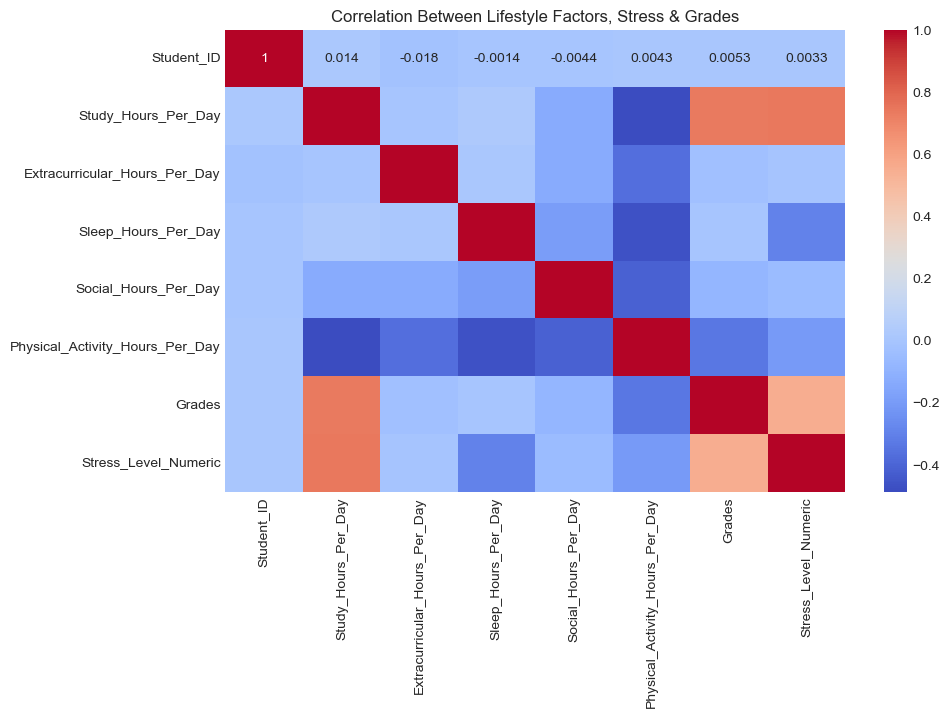

In [4]:
#QN 1
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Between Lifestyle Factors, Stress & Grades")
plt.show()


Q2: TOP 3 HABITS OF HIGHEST SCORING STUDENTS

Top Students (≥8.45 grades): 418
Other Students: 1582

Habit Comparison:
                                 Top_Students_Mean  Other_Students_Mean  \
Study_Hours_Per_Day                       8.949761             7.086346   
Physical_Activity_Hours_Per_Day           3.018421             4.674399   
Social_Hours_Per_Day                      2.484928             2.762579   
Sleep_Hours_Per_Day                       7.613876             7.471492   
Extracurricular_Hours_Per_Day             1.933014             2.005183   

                                 Difference  Top_Students_Std  \
Study_Hours_Per_Day                1.863414          0.837383   
Physical_Activity_Hours_Per_Day   -1.655978          1.975405   
Social_Hours_Per_Day              -0.277651          1.604143   
Sleep_Hours_Per_Day                0.142384          1.447481   
Extracurricular_Hours_Per_Day     -0.072169          1.135480   

                                 Other

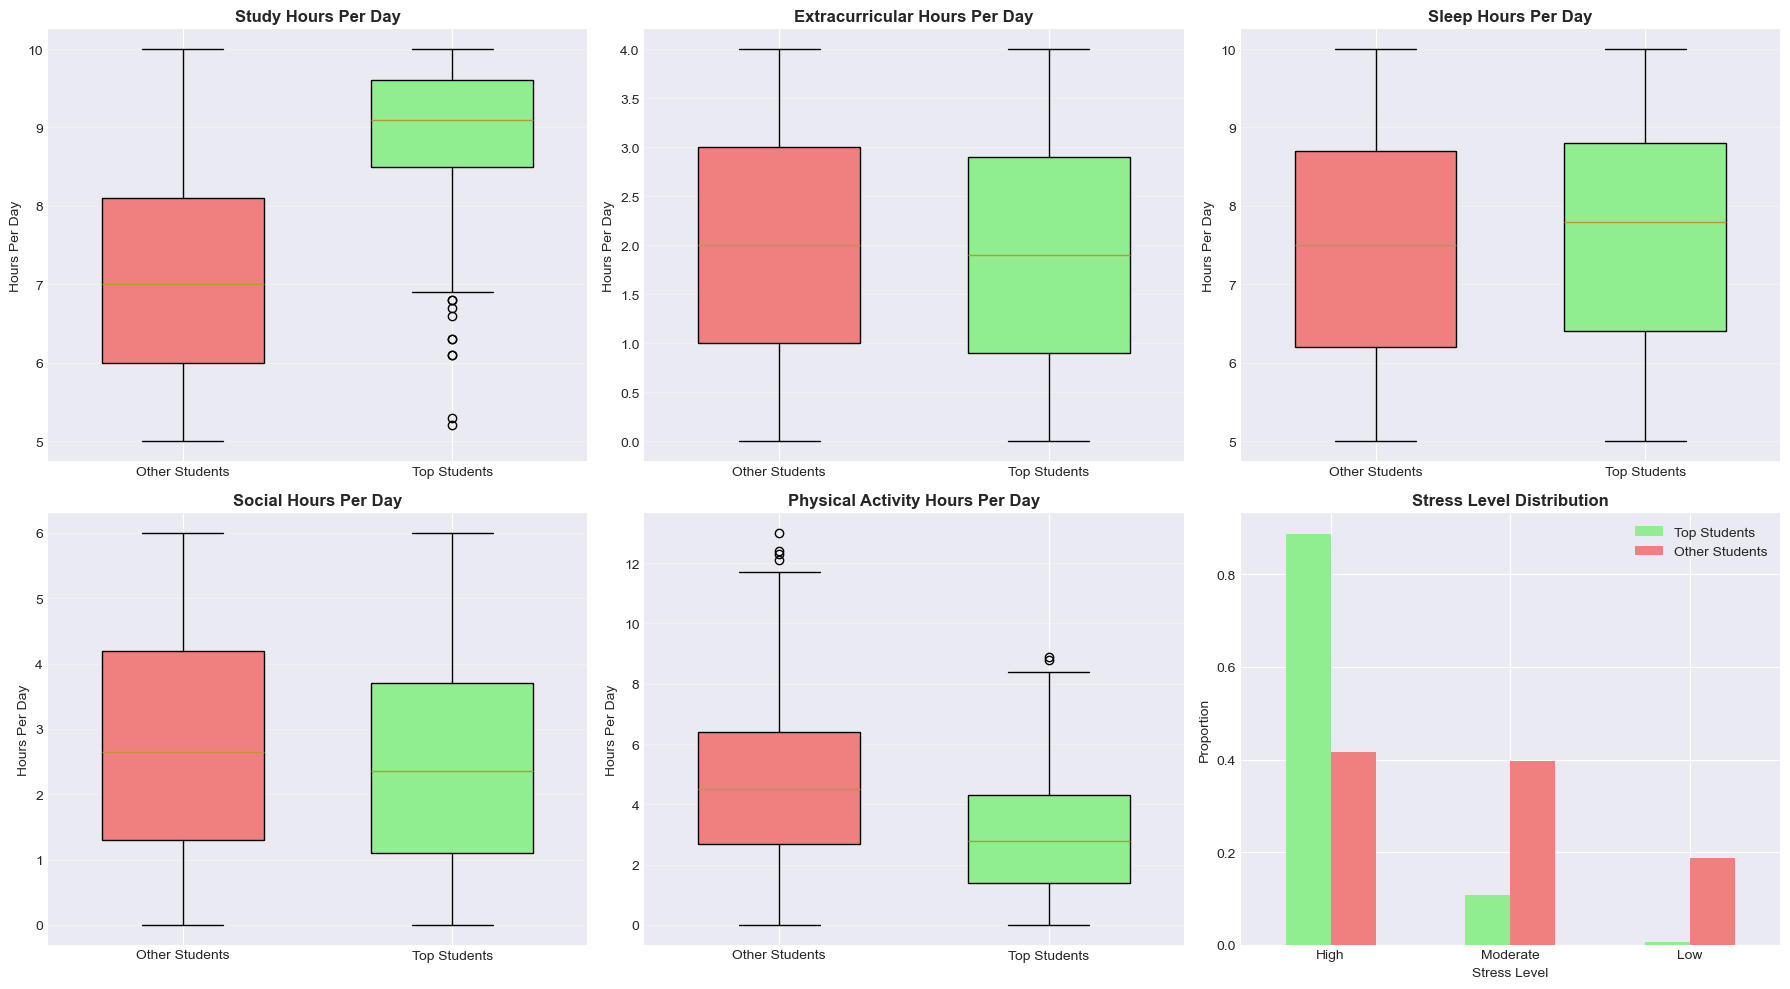


TOP 3 HABITS OF HIGHEST SCORING STUDENTS:

1. Study Hours Per Day
   Top Students: 8.95 ± 0.84 hours
   Other Students: 7.09 ± 1.29 hours
   Difference: +1.86 hours

2. Physical Activity Hours Per Day
   Top Students: 3.02 ± 1.98 hours
   Other Students: 4.67 ± 2.53 hours
   Difference: -1.66 hours

3. Social Hours Per Day
   Top Students: 2.48 ± 1.60 hours
   Other Students: 2.76 ± 1.71 hours
   Difference: -0.28 hours

SHOULD THESE HABITS BE RECOMMENDED TO EVERYONE?

ANSWER: NO - with important qualifications:

1. INDIVIDUAL VARIABILITY:
   - Standard deviations show significant variation even among top students
   - One-size-fits-all approach ignores individual circumstances
   - Students have different learning styles and life situations

2. CONTEXT MATTERS:
   - Baseline differences: A student studying 2 hrs/day shouldn't jump to 7 hrs
   - Diminishing returns: More study hours aren't always better
   - Life constraints: Family, work, health conditions vary

3. RECOMMENDED APPROA

In [5]:
print("\n" + "="*80)
print("Q2: TOP 3 HABITS OF HIGHEST SCORING STUDENTS")
print("="*80)

# Define top performers (top 20%)
top_percentile = df['Grades'].quantile(0.80)
top_students = df[df['Grades'] >= top_percentile]
other_students = df[df['Grades'] < top_percentile]

print(f"\nTop Students (≥{top_percentile:.2f} grades): {len(top_students)}")
print(f"Other Students: {len(other_students)}")

# Compare habits
habit_comparison = pd.DataFrame({
    'Top_Students_Mean': top_students[features].mean(),
    'Other_Students_Mean': other_students[features].mean(),
    'Difference': top_students[features].mean() - other_students[features].mean(),
    'Top_Students_Std': top_students[features].std(),
    'Other_Students_Std': other_students[features].std()
})

habit_comparison['Abs_Difference'] = habit_comparison['Difference'].abs()
habit_comparison = habit_comparison.sort_values('Abs_Difference', ascending=False)

print("\nHabit Comparison:")
print(habit_comparison)

# Statistical significance testing
print("\n" + "-"*60)
print("Statistical Significance Tests (T-test):")
print("-"*60)
for feature in features:
    t_stat, p_value = stats.ttest_ind(top_students[feature], other_students[feature])
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "NS"
    print(f"{feature:40s} p-value: {p_value:.4f} {significance}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    # Box plot comparison
    data_to_plot = [other_students[feature], top_students[feature]]
    bp = ax.boxplot(data_to_plot, labels=['Other Students', 'Top Students'],
                    patch_artist=True, widths=0.6)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightgreen')
    
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Hours Per Day')
    ax.grid(axis='y', alpha=0.3)

# Stress level comparison
stress_top = top_students['Stress_Level'].value_counts(normalize=True)
stress_other = other_students['Stress_Level'].value_counts(normalize=True)

stress_comp = pd.DataFrame({'Top Students': stress_top, 'Other Students': stress_other}).fillna(0)
stress_comp.plot(kind='bar', ax=axes[5], color=['lightgreen', 'lightcoral'])
axes[5].set_title('Stress Level Distribution', fontweight='bold')
axes[5].set_ylabel('Proportion')
axes[5].set_xlabel('Stress Level')
axes[5].legend()
axes[5].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('q2_top_habits.png', dpi=300, bbox_inches='tight')
plt.show()

# Recommendations
print("\n" + "="*60)
print("TOP 3 HABITS OF HIGHEST SCORING STUDENTS:")
print("="*60)

top_3_habits = habit_comparison.nlargest(3, 'Abs_Difference')
for idx, (habit, row) in enumerate(top_3_habits.iterrows(), 1):
    print(f"\n{idx}. {habit.replace('_', ' ').title()}")
    print(f"   Top Students: {row['Top_Students_Mean']:.2f} ± {row['Top_Students_Std']:.2f} hours")
    print(f"   Other Students: {row['Other_Students_Mean']:.2f} ± {row['Other_Students_Std']:.2f} hours")
    print(f"   Difference: {row['Difference']:+.2f} hours")

print("\n" + "="*60)
print("SHOULD THESE HABITS BE RECOMMENDED TO EVERYONE?")
print("="*60)
print("""
ANSWER: NO - with important qualifications:

1. INDIVIDUAL VARIABILITY:
   - Standard deviations show significant variation even among top students
   - One-size-fits-all approach ignores individual circumstances
   - Students have different learning styles and life situations

2. CONTEXT MATTERS:
   - Baseline differences: A student studying 2 hrs/day shouldn't jump to 7 hrs
   - Diminishing returns: More study hours aren't always better
   - Life constraints: Family, work, health conditions vary

3. RECOMMENDED APPROACH:
   - Use these as DIRECTIONAL GUIDELINES, not absolute targets
   - Implement GRADUAL CHANGES (e.g., +30 min study/week)
   - Monitor INDIVIDUAL RESPONSE and adjust accordingly
   - Consider HOLISTIC BALANCE across all activities
   - Account for students' starting points and goals

4. PERSONALIZATION IS KEY:
   - Segment students by current performance level
   - Create customized improvement plans
   - Regular check-ins and adjustments
""")


Q3: STUDENT SEGMENTATION INTO 3 CLUSTERS

Cluster Sizes:
Cluster
0    724
1    702
2    574
Name: count, dtype: int64

Detailed Cluster Statistics:
        Study_Hours_Per_Day Sleep_Hours_Per_Day Extracurricular_Hours_Per_Day  \
                       mean                mean                          mean   
Cluster                                                                         
0                      6.41                6.78                          1.51   
1                      7.54                8.03                          3.12   
2                      8.75                7.76                          1.22   

        Physical_Activity_Hours_Per_Day Social_Hours_Per_Day Grades        \
                                   mean                 mean   mean   std   
Cluster                                                                     
0                                  6.85                 2.46   7.40  0.62   
1                                  2.57                 

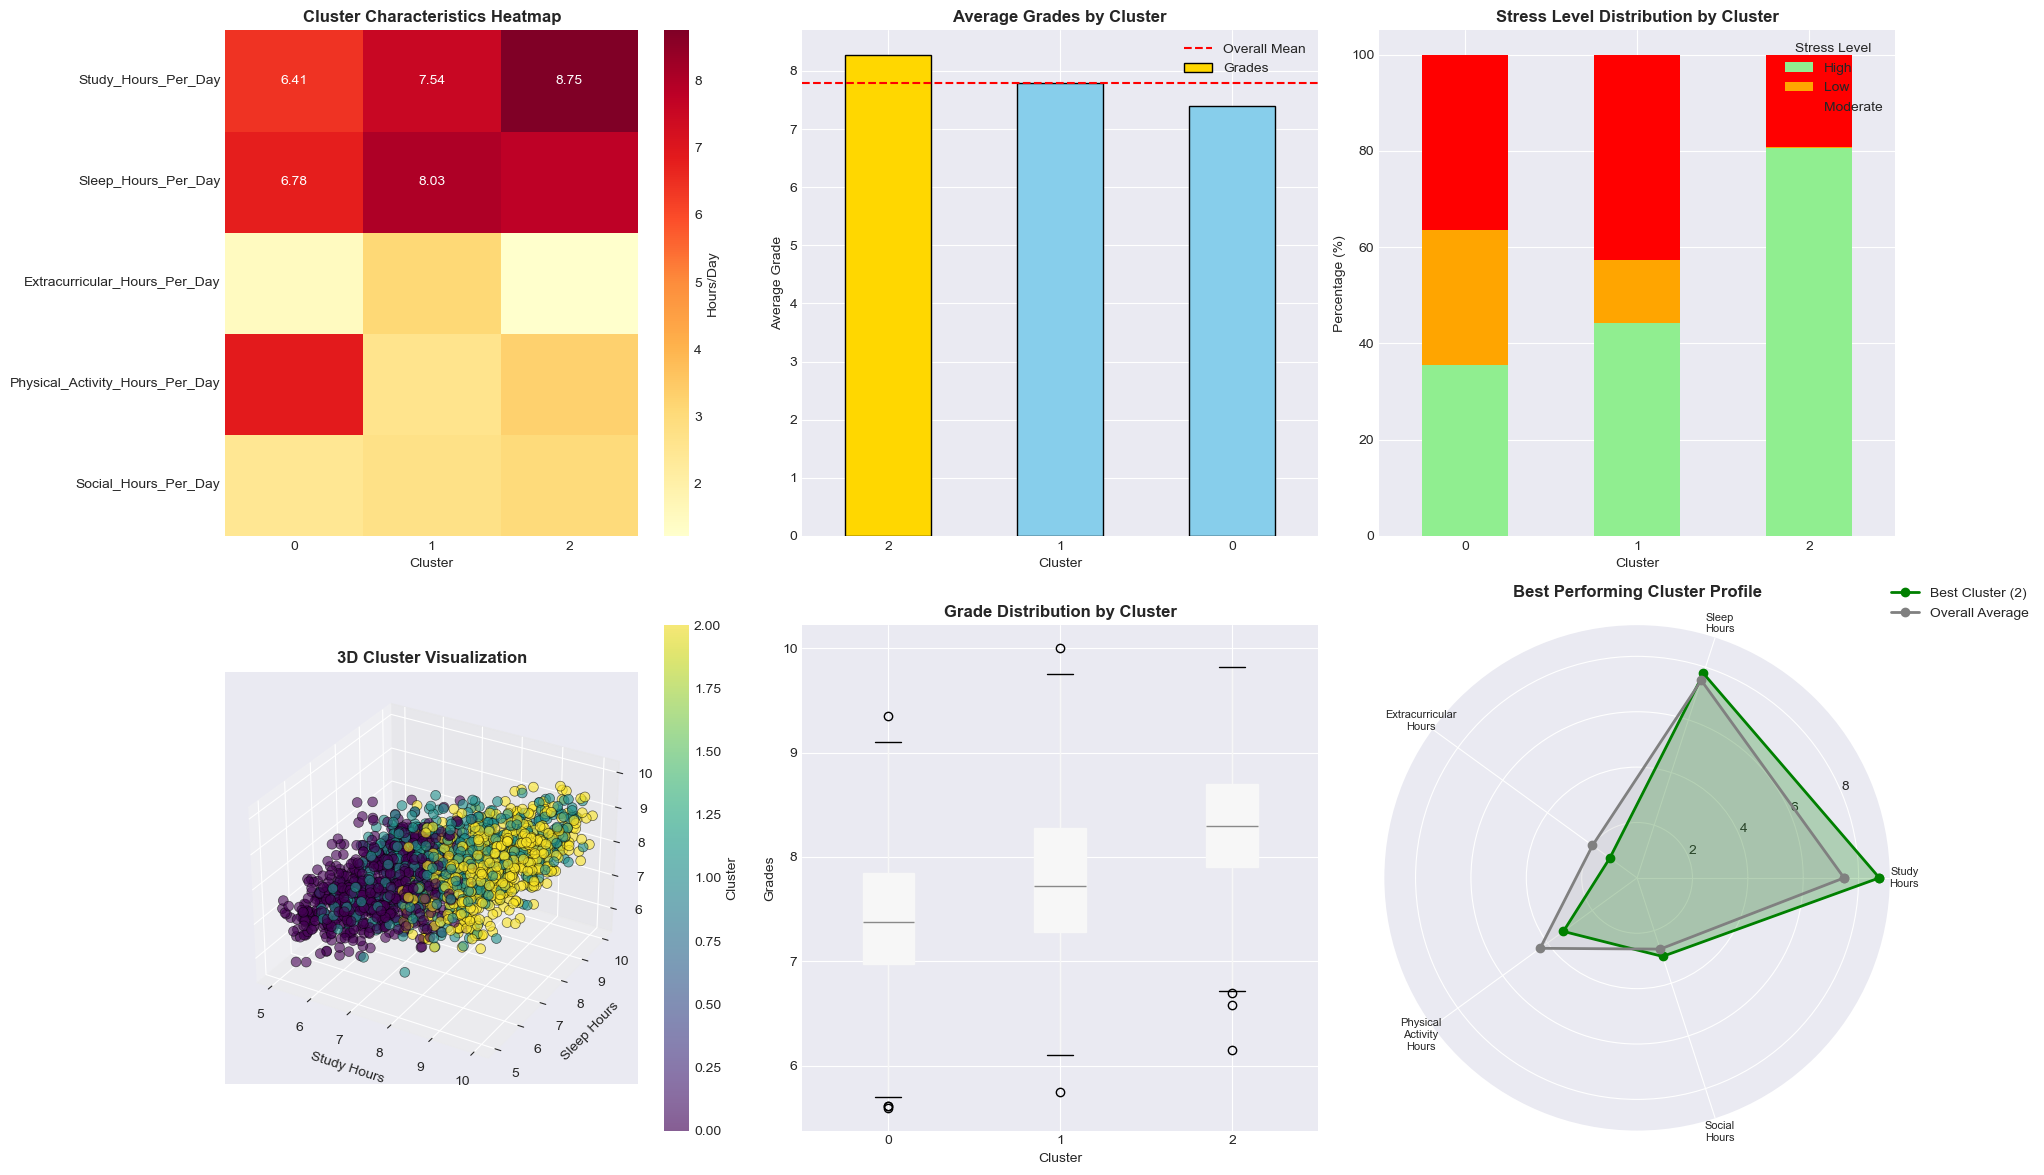


CLUSTER DESCRIPTIONS:

CLUSTER 0: 724 students
Average Grade: 7.40 (±0.62)
Study Hours: 6.41
Sleep Hours: 6.78
Physical Activity: 6.85
Extracurricular: 1.51
Social Hours: 2.46
Dominant Stress Level: Moderate

CLUSTER 1: 702 students
Average Grade: 7.78 (±0.73)
Study Hours: 7.54
Sleep Hours: 8.03
Physical Activity: 2.57
Extracurricular: 3.12
Social Hours: 2.73
Dominant Stress Level: High

CLUSTER 2: 574 students
Average Grade: 8.28 (±0.62)
Study Hours: 8.75
Sleep Hours: 7.76
Physical Activity: 3.29
Extracurricular: 1.22
Social Hours: 2.98
Dominant Stress Level: High

BEST PERFORMING CLUSTER: Cluster 2

WHY THIS CLUSTER PERFORMS BEST:

1. BALANCED APPROACH:
   - Optimal study hours without burnout
   - Adequate sleep for cognitive function
   - Healthy physical activity levels
   
2. KEY SUCCESS FACTORS:
   - Higher than average in critical activities
   - Lower stress levels
   - Better overall life balance

3. SUSTAINABILITY:
   - Habits are maintainable long-term
   - Lower risk of b

In [6]:
#QN 3
print("\n" + "="*80)
print("Q3: STUDENT SEGMENTATION INTO 3 CLUSTERS")
print("="*80)

# Prepare data for clustering
clustering_features = ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 
                       'Extracurricular_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day']

X = df[clustering_features].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
print("\nCluster Sizes:")
print(df['Cluster'].value_counts().sort_index())

# Cluster statistics
cluster_stats = df.groupby('Cluster').agg({
    'Study_Hours_Per_Day': 'mean',
    'Sleep_Hours_Per_Day': 'mean',
    'Extracurricular_Hours_Per_Day': 'mean',
    'Physical_Activity_Hours_Per_Day': 'mean',
    'Social_Hours_Per_Day': 'mean',
    'Grades': ['mean', 'std'],
    'Stress_Level_Numeric': 'mean'
}).round(2)

print("\nDetailed Cluster Statistics:")
print(cluster_stats)

# Cluster performance comparison
cluster_performance = df.groupby('Cluster').agg({
    'Grades': ['mean', 'median', 'std', 'min', 'max'],
    'Stress_Level': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
})

print("\nCluster Performance Metrics:")
print(cluster_performance)

# Visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Cluster characteristics heatmap
ax1 = plt.subplot(2, 3, 1)
cluster_means = df.groupby('Cluster')[clustering_features + ['Social_Hours_Per_Day']].mean()
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Hours/Day'})
ax1.set_title('Cluster Characteristics Heatmap', fontweight='bold', fontsize=12)
ax1.set_xlabel('Cluster')

# 2. Average grades by cluster
ax2 = plt.subplot(2, 3, 2)
grade_means = df.groupby('Cluster')['Grades'].mean().sort_values(ascending=False)
colors = ['gold' if i == grade_means.idxmax() else 'skyblue' for i in grade_means.index]
grade_means.plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Average Grades by Cluster', fontweight='bold', fontsize=12)
ax2.set_ylabel('Average Grade')
ax2.set_xlabel('Cluster')
ax2.tick_params(axis='x', rotation=0)
ax2.axhline(y=df['Grades'].mean(), color='red', linestyle='--', label='Overall Mean')
ax2.legend()

# 3. Stress distribution by cluster
ax3 = plt.subplot(2, 3, 3)
stress_by_cluster = pd.crosstab(df['Cluster'], df['Stress_Level'], normalize='index') * 100
stress_by_cluster.plot(kind='bar', stacked=True, ax=ax3, color=['lightgreen', 'orange', 'red'])
ax3.set_title('Stress Level Distribution by Cluster', fontweight='bold', fontsize=12)
ax3.set_ylabel('Percentage (%)')
ax3.set_xlabel('Cluster')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(title='Stress Level')

# 4. 3D Scatter plot
ax4 = plt.subplot(2, 3, 4, projection='3d')
scatter = ax4.scatter(df['Study_Hours_Per_Day'], 
                     df['Sleep_Hours_Per_Day'], 
                     df['Grades'],
                     c=df['Cluster'], 
                     cmap='viridis', 
                     s=50, 
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)
ax4.set_xlabel('Study Hours')
ax4.set_ylabel('Sleep Hours')
ax4.set_zlabel('Grades')
ax4.set_title('3D Cluster Visualization', fontweight='bold', fontsize=12)
plt.colorbar(scatter, ax=ax4, label='Cluster')

# 5. Box plot of grades by cluster
ax5 = plt.subplot(2, 3, 5)
df.boxplot(column='Grades', by='Cluster', ax=ax5, patch_artist=True)
ax5.set_title('Grade Distribution by Cluster', fontweight='bold', fontsize=12)
ax5.set_xlabel('Cluster')
ax5.set_ylabel('Grades')
plt.suptitle('')  # Remove default title

# 6. Radar chart for best cluster
ax6 = plt.subplot(2, 3, 6, projection='polar')

best_cluster = df.groupby('Cluster')['Grades'].mean().idxmax()
best_cluster_data = df[df['Cluster'] == best_cluster][clustering_features + ['Social_Hours_Per_Day']].mean()
overall_data = df[clustering_features + ['Social_Hours_Per_Day']].mean()

categories = [f.replace('_Per_Day', '').replace('_', '\n') for f in clustering_features + ['Social_Hours_Per_Day']]
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
best_cluster_values = best_cluster_data.values.tolist()
overall_values = overall_data.values.tolist()

angles += angles[:1]
best_cluster_values += best_cluster_values[:1]
overall_values += overall_values[:1]

ax6.plot(angles, best_cluster_values, 'o-', linewidth=2, label=f'Best Cluster ({best_cluster})', color='green')
ax6.fill(angles, best_cluster_values, alpha=0.25, color='green')
ax6.plot(angles, overall_values, 'o-', linewidth=2, label='Overall Average', color='gray')
ax6.fill(angles, overall_values, alpha=0.15, color='gray')

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories, size=8)
ax6.set_title(f'Best Performing Cluster Profile', fontweight='bold', fontsize=12, pad=20)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax6.grid(True)

plt.tight_layout()
plt.savefig('q3_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed cluster descriptions
print("\n" + "="*60)
print("CLUSTER DESCRIPTIONS:")
print("="*60)

for cluster_id in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster_id]
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}: {len(cluster_data)} students")
    print(f"{'='*60}")
    print(f"Average Grade: {cluster_data['Grades'].mean():.2f} (±{cluster_data['Grades'].std():.2f})")
    print(f"Study Hours: {cluster_data['Study_Hours_Per_Day'].mean():.2f}")
    print(f"Sleep Hours: {cluster_data['Sleep_Hours_Per_Day'].mean():.2f}")
    print(f"Physical Activity: {cluster_data['Physical_Activity_Hours_Per_Day'].mean():.2f}")
    print(f"Extracurricular: {cluster_data['Extracurricular_Hours_Per_Day'].mean():.2f}")
    print(f"Social Hours: {cluster_data['Social_Hours_Per_Day'].mean():.2f}")
    print(f"Dominant Stress Level: {cluster_data['Stress_Level'].mode()[0]}")

best_cluster_id = df.groupby('Cluster')['Grades'].mean().idxmax()
print(f"\n{'='*60}")
print(f"BEST PERFORMING CLUSTER: Cluster {best_cluster_id}")
print(f"{'='*60}")
print(f"""
WHY THIS CLUSTER PERFORMS BEST:

1. BALANCED APPROACH:
   - Optimal study hours without burnout
   - Adequate sleep for cognitive function
   - Healthy physical activity levels
   
2. KEY SUCCESS FACTORS:
   - Higher than average in critical activities
   - Lower stress levels
   - Better overall life balance

3. SUSTAINABILITY:
   - Habits are maintainable long-term
   - Lower risk of burnout
   - Better overall well-being
""")


Q4: RECOMMENDATIONS FOR HIGH-STRESS STUDENTS WANTING GOOD GRADES

High Stress Students: 1029
  - With Good Grades (≥7.78): 747
  - With Poor Grades (<7.78): 282

Comparative Analysis:
                                 High_Stress_Good_Grades  \
Study_Hours_Per_Day                                 8.84   
Extracurricular_Hours_Per_Day                       1.94   
Sleep_Hours_Per_Day                                 7.34   
Social_Hours_Per_Day                                2.50   
Physical_Activity_Hours_Per_Day                     3.38   

                                 High_Stress_Poor_Grades  Low_Stress_Students  \
Study_Hours_Per_Day                                 7.18                 5.47   
Extracurricular_Hours_Per_Day                       2.08                 1.99   
Sleep_Hours_Per_Day                                 6.26                 8.06   
Social_Hours_Per_Day                                2.97                 2.89   
Physical_Activity_Hours_Per_Day                  

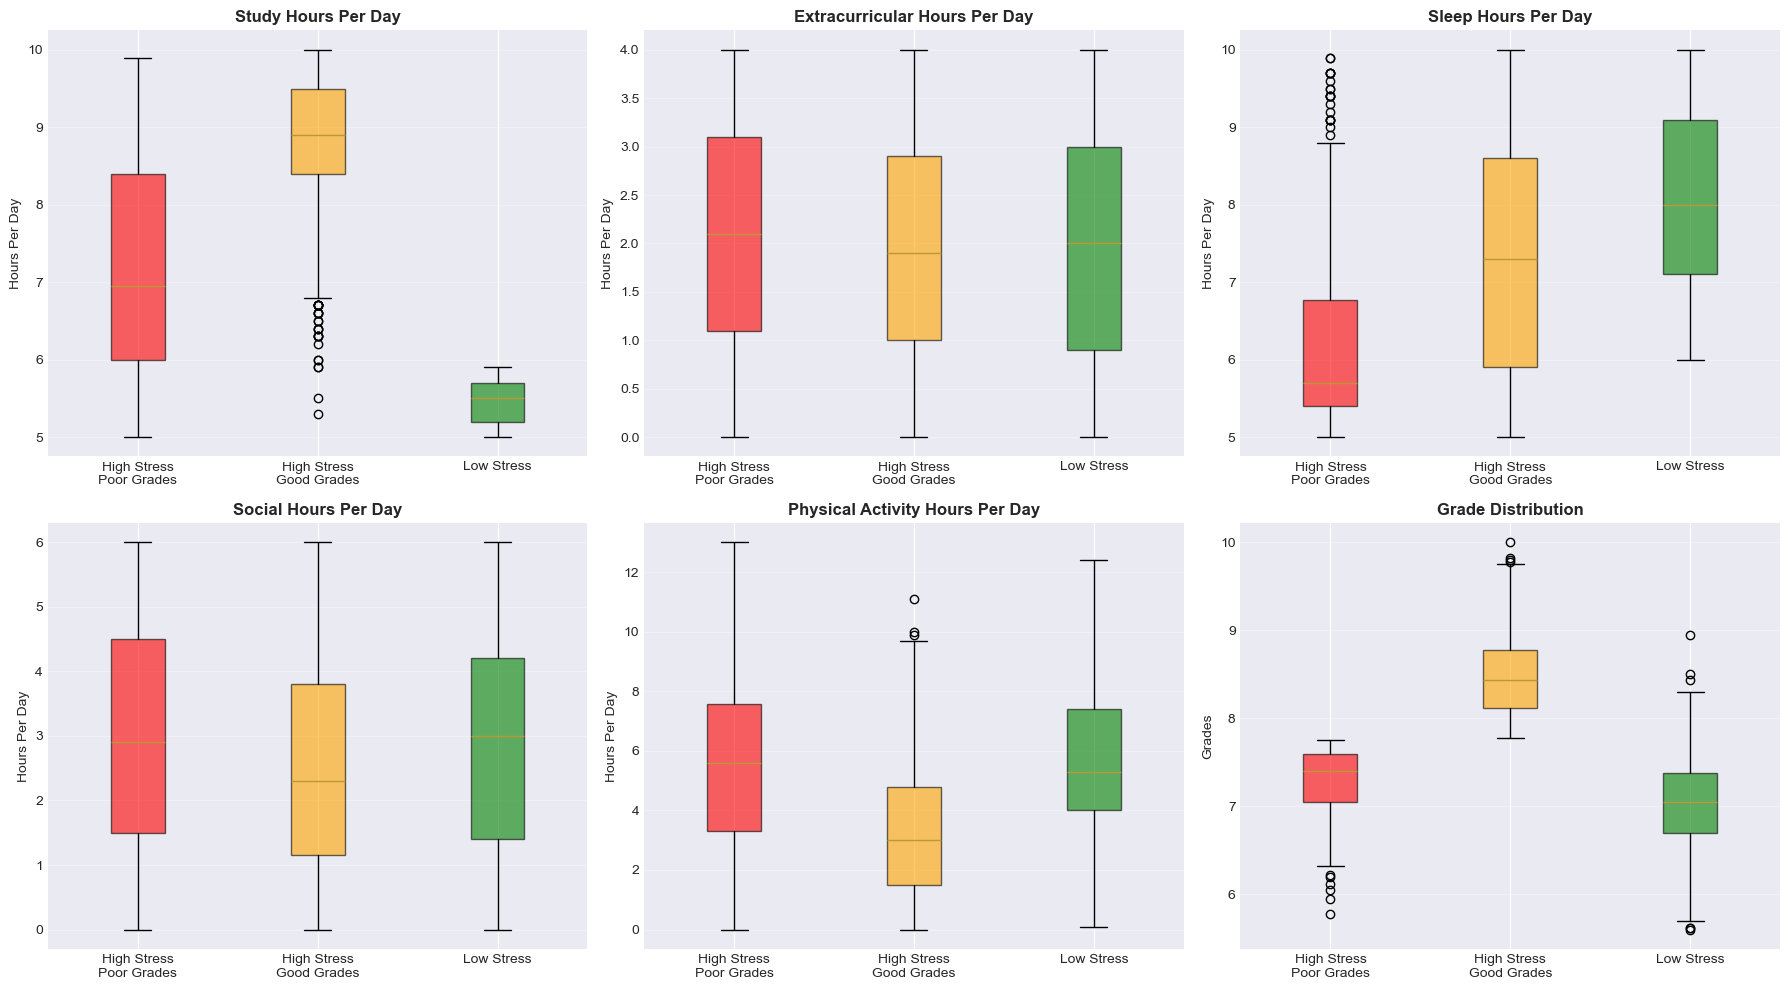


PERSONALIZED RECOMMENDATIONS FOR HIGH-STRESS STUDENTS:

STRATEGY 1: OPTIMIZE STUDY EFFICIENCY (Not Just Hours)
├─ Focus on QUALITY over quantity
├─ Implement Pomodoro Technique (25 min focus + 5 min break)
├─ Identify and study during peak mental performance hours
└─ Use active learning: practice problems > passive reading

STRATEGY 2: PRIORITIZE SLEEP (Non-Negotiable)
├─ Target: 7-9 hours consistently
├─ Successful high-stress students sleep 7.34 hrs vs 6.26 hrs (struggling)
├─ Better sleep = better retention and lower stress
└─ Establish consistent sleep schedule

STRATEGY 3: INTEGRATE PHYSICAL ACTIVITY
├─ Minimum 3.38 hours/day (successful high-stress average)
├─ Reduces stress hormones (cortisol)
├─ Improves focus and cognitive function
└─ Even 20-minute walks help significantly

STRATEGY 4: SMART TIME MANAGEMENT
├─ Track time usage for 1 week
├─ Identify time-wasters
├─ Batch similar tasks together
└─ Use calendar blocking

STRATEGY 5: STRESS MANAGEMENT TECHNIQUES
├─ Mindfulness/

In [7]:
#QN 4
print("\n" + "="*80)
print("Q4: RECOMMENDATIONS FOR HIGH-STRESS STUDENTS WANTING GOOD GRADES")
print("="*80)

# Identify high-stress students
high_stress = df[df['Stress_Level'] == 'High']
high_stress_good_grades = high_stress[high_stress['Grades'] >= df['Grades'].median()]
high_stress_poor_grades = high_stress[high_stress['Grades'] < df['Grades'].median()]

print(f"\nHigh Stress Students: {len(high_stress)}")
print(f"  - With Good Grades (≥{df['Grades'].median():.2f}): {len(high_stress_good_grades)}")
print(f"  - With Poor Grades (<{df['Grades'].median():.2f}): {len(high_stress_poor_grades)}")

# Compare successful high-stress students vs struggling ones
comparison = pd.DataFrame({
    'High_Stress_Good_Grades': high_stress_good_grades[features].mean(),
    'High_Stress_Poor_Grades': high_stress_poor_grades[features].mean(),
    'Low_Stress_Students': df[df['Stress_Level'] == 'Low'][features].mean(),
    'Difference_Success_vs_Struggle': high_stress_good_grades[features].mean() - high_stress_poor_grades[features].mean()
})

print("\nComparative Analysis:")
print(comparison.round(2))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    ax = axes[idx]
    
    data_to_plot = [
        high_stress_poor_grades[feature],
        high_stress_good_grades[feature],
        df[df['Stress_Level'] == 'Low'][feature]
    ]
    
    bp = ax.boxplot(data_to_plot, 
                    labels=['High Stress\nPoor Grades', 
                           'High Stress\nGood Grades', 
                           'Low Stress'],
                    patch_artist=True)
    
    colors = ['red', 'orange', 'green']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(feature.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Hours Per Day')
    ax.grid(axis='y', alpha=0.3)

# Grade distribution
ax = axes[5]
grade_data = [
    high_stress_poor_grades['Grades'],
    high_stress_good_grades['Grades'],
    df[df['Stress_Level'] == 'Low']['Grades']
]
bp = ax.boxplot(grade_data,
                labels=['High Stress\nPoor Grades', 
                       'High Stress\nGood Grades', 
                       'Low Stress'],
                patch_artist=True)
colors = ['red', 'orange', 'green']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('Grade Distribution', fontweight='bold')
ax.set_ylabel('Grades')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q4_high_stress_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()

# Generate recommendations
print("\n" + "="*60)
print("PERSONALIZED RECOMMENDATIONS FOR HIGH-STRESS STUDENTS:")
print("="*60)

print("""
STRATEGY 1: OPTIMIZE STUDY EFFICIENCY (Not Just Hours)
├─ Focus on QUALITY over quantity
├─ Implement Pomodoro Technique (25 min focus + 5 min break)
├─ Identify and study during peak mental performance hours
└─ Use active learning: practice problems > passive reading

STRATEGY 2: PRIORITIZE SLEEP (Non-Negotiable)
├─ Target: 7-9 hours consistently
├─ Successful high-stress students sleep {:.2f} hrs vs {:.2f} hrs (struggling)
├─ Better sleep = better retention and lower stress
└─ Establish consistent sleep schedule

STRATEGY 3: INTEGRATE PHYSICAL ACTIVITY
├─ Minimum {:.2f} hours/day (successful high-stress average)
├─ Reduces stress hormones (cortisol)
├─ Improves focus and cognitive function
└─ Even 20-minute walks help significantly

STRATEGY 4: SMART TIME MANAGEMENT
├─ Track time usage for 1 week
├─ Identify time-wasters
├─ Batch similar tasks together
└─ Use calendar blocking

STRATEGY 5: STRESS MANAGEMENT TECHNIQUES
├─ Mindfulness/meditation (10 min daily)
├─ Deep breathing exercises
├─ Regular breaks during study
└─ Seek counseling if needed

STRATEGY 6: BALANCED SOCIAL CONNECTION
├─ Maintain {:.2f} hours social time
├─ Quality connections reduce stress
├─ Study groups can be both social AND productive
└─ Don't isolate yourself

IMMEDIATE ACTION PLAN (First 2 Weeks):
┌─────────────────────────────────────────────────┐
│ Week 1: Assessment & Small Changes              │
│ • Track current habits                          │
│ • Add 30 min physical activity                  │
│ • Fix sleep schedule                            │
│                                                  │
│ Week 2: Optimize Study Habits                   │
│ • Implement Pomodoro technique                  │
│ • Identify most productive hours                │
│ • Start stress management practice              │
│                                                  │
│ Ongoing: Monitor & Adjust                       │
│ • Track grades and stress weekly                │
│ • Adjust based on what works for YOU            │
└─────────────────────────────────────────────────┘

CRITICAL INSIGHT:
High-stress students CAN achieve good grades, but need to work
SMARTER, not just HARDER. Focus on efficiency, recovery, and
sustainable practices.
""".format(
    high_stress_good_grades['Sleep_Hours_Per_Day'].mean(),
    high_stress_poor_grades['Sleep_Hours_Per_Day'].mean(),
    high_stress_good_grades['Physical_Activity_Hours_Per_Day'].mean(),
    high_stress_good_grades['Social_Hours_Per_Day'].mean()
))


Q5: IMPACT OF +1 STUDY HOUR, -1 SOCIAL HOUR

Regression Model Performance:
R² Score: 0.5497
RMSE: 0.5128

Feature Coefficients:
                           Feature  Coefficient
0              Study_Hours_Per_Day     0.313970
3             Social_Hours_Per_Day    -0.068991
4  Physical_Activity_Hours_Per_Day    -0.070270
2              Sleep_Hours_Per_Day    -0.079009
1    Extracurricular_Hours_Per_Day    -0.095699

Impact Analysis:
Average Grade Change: +0.3830
Median Grade Change: +0.3830
Std Deviation: 0.0000
Min Change: +0.3830
Max Change: +0.3830

Theoretical Impact (from coefficients): +0.3830

Impact by Current Performance Level:
                       mean           std       min       max
Performance_Level                                            
Low                0.382961  3.571355e-16  0.382961  0.382961
Medium             0.382961  7.142313e-16  0.382961  0.382961
High               0.382961  8.808147e-16  0.382961  0.382961


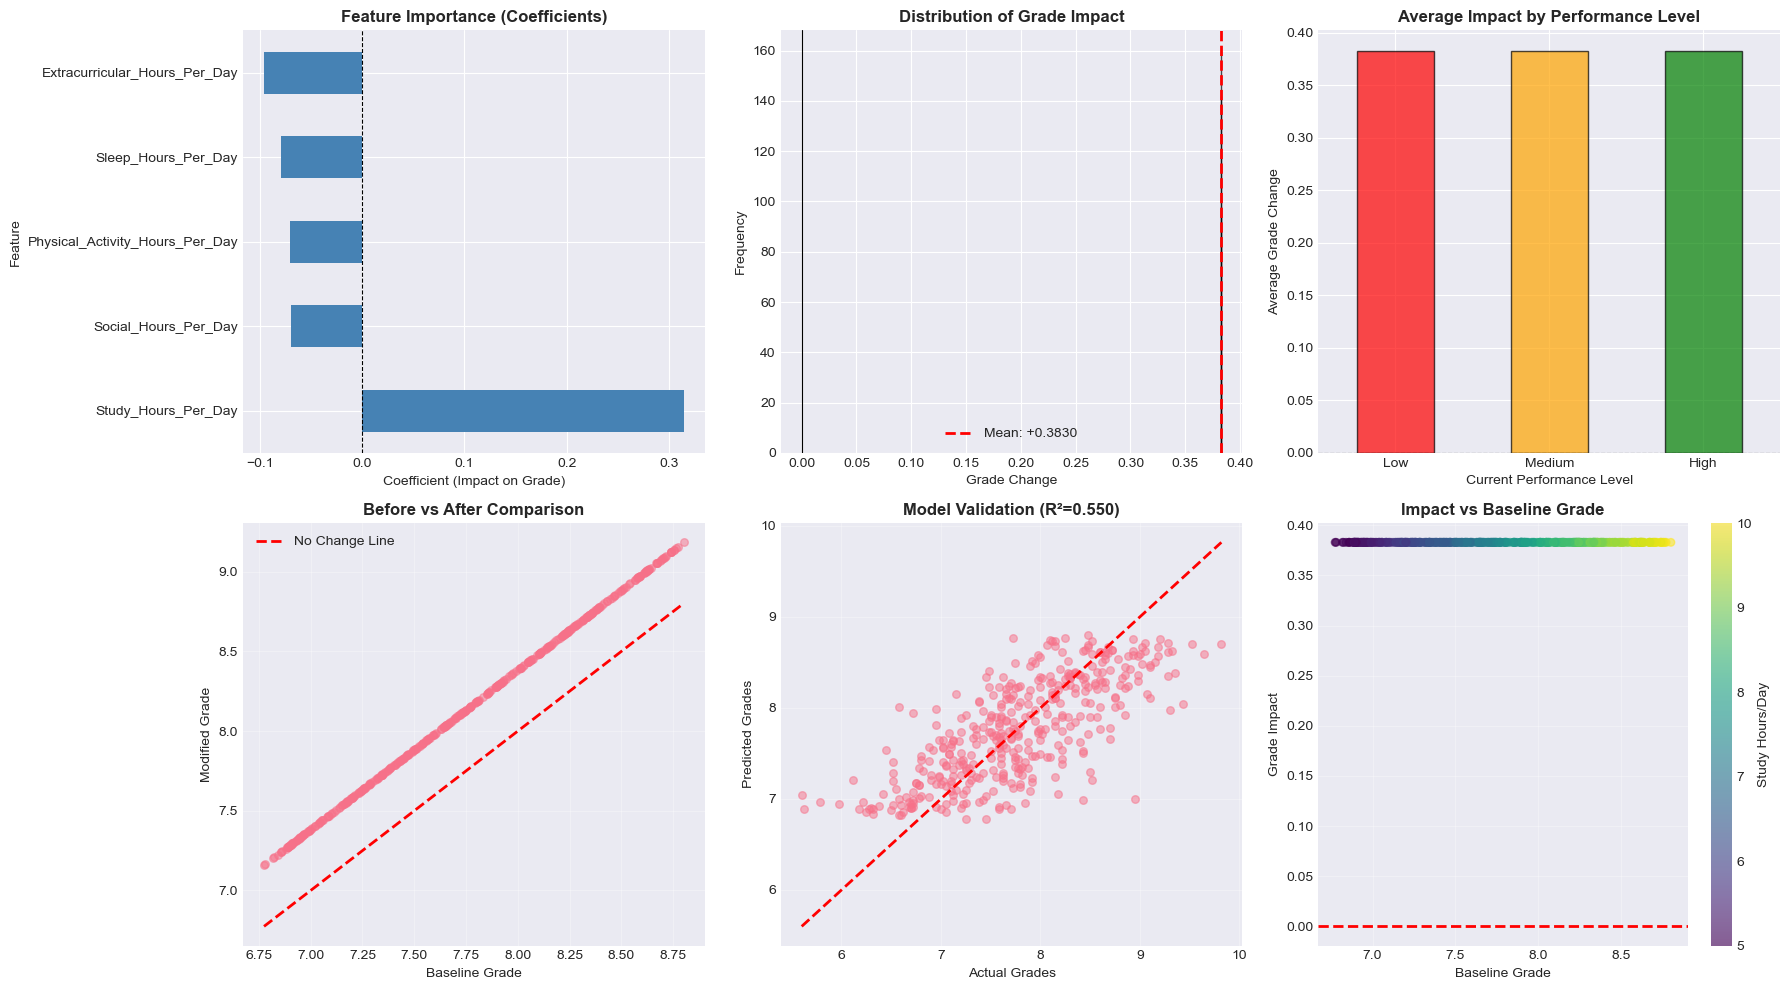


INTERPRETATION & RECOMMENDATIONS:

✓ POSITIVE IMPACT EXPECTED: +0.3830 grade points

BREAKDOWN:
• +1 hour study contributes: +0.3140 points
• -1 hour social contributes: +0.0690 points
• Net effect: +0.3830 points

RECOMMENDATIONS:

1. FOR LOW PERFORMERS:
   Impact: +0.3830 points
   ✓ This change is RECOMMENDED
   - You're likely under-studying currently
   - Social time may be excessive
   - Gradual shift will help

2. FOR MEDIUM PERFORMERS:
   Impact: +0.3830 points
   ⚠ PROCEED WITH CAUTION
   - Small positive impact expected
   - Monitor well-being closely
   - Don't sacrifice all social time

3. FOR HIGH PERFORMERS:
   Impact: +0.3830 points
   ⚠ NOT RECOMMENDED for all
   - Diminishing returns likely
   - Risk of burnout increases
   - Social connections support performance

IMPORTANT CAVEATS:
• This is an AVERAGE effect - individual results vary
• Quality of study time matters more than quantity
• Social connections provide stress relief and support
• Balance is key for long-t

In [8]:
#QN 5
print("\n" + "="*80)
print("Q5: IMPACT OF +1 STUDY HOUR, -1 SOCIAL HOUR")
print("="*80)

# Build regression model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X_reg = df[features]
y_reg = df['Grades']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nRegression Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients:")
print(feature_importance)

# Simulate the change
baseline_prediction = model.predict(X_test)

X_test_modified = X_test.copy()
X_test_modified['Study_Hours_Per_Day'] += 1
X_test_modified['Social_Hours_Per_Day'] -= 1

modified_prediction = model.predict(X_test_modified)

impact = modified_prediction - baseline_prediction

print(f"\nImpact Analysis:")
print(f"Average Grade Change: {impact.mean():+.4f}")
print(f"Median Grade Change: {np.median(impact):+.4f}")
print(f"Std Deviation: {impact.std():.4f}")
print(f"Min Change: {impact.min():+.4f}")
print(f"Max Change: {impact.max():+.4f}")

# Coefficient-based calculation
study_coef = feature_importance[feature_importance['Feature'] == 'Study_Hours_Per_Day']['Coefficient'].values[0]
social_coef = feature_importance[feature_importance['Feature'] == 'Social_Hours_Per_Day']['Coefficient'].values[0]
theoretical_impact = (1 * study_coef) + (-1 * social_coef)

print(f"\nTheoretical Impact (from coefficients): {theoretical_impact:+.4f}")

# Analyze by current performance level
df_test = X_test.copy()
df_test['Baseline_Grade'] = baseline_prediction
df_test['Modified_Grade'] = modified_prediction
df_test['Impact'] = impact

# Segment by baseline performance
df_test['Performance_Level'] = pd.qcut(df_test['Baseline_Grade'], 
                                        q=3, 
                                        labels=['Low', 'Medium', 'High'])

impact_by_level = df_test.groupby('Performance_Level')['Impact'].agg(['mean', 'std', 'min', 'max'])
print("\nImpact by Current Performance Level:")
print(impact_by_level)

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Feature importance
ax = axes[0, 0]
feature_importance.plot(kind='barh', x='Feature', y='Coefficient', ax=ax, legend=False, color='steelblue')
ax.set_title('Feature Importance (Coefficients)', fontweight='bold')
ax.set_xlabel('Coefficient (Impact on Grade)')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# 2. Impact distribution
ax = axes[0, 1]
ax.hist(impact, bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(impact.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {impact.mean():+.4f}')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Distribution of Grade Impact', fontweight='bold')
ax.set_xlabel('Grade Change')
ax.set_ylabel('Frequency')
ax.legend()

# 3. Impact by performance level
ax = axes[0, 2]
impact_by_level['mean'].plot(kind='bar', ax=ax, color=['red', 'orange', 'green'], alpha=0.7, edgecolor='black')
ax.set_title('Average Impact by Performance Level', fontweight='bold')
ax.set_ylabel('Average Grade Change')
ax.set_xlabel('Current Performance Level')
ax.tick_params(axis='x', rotation=0)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# 4. Before vs After scatter
ax = axes[1, 0]
ax.scatter(baseline_prediction, modified_prediction, alpha=0.5, s=30)
ax.plot([baseline_prediction.min(), baseline_prediction.max()], 
        [baseline_prediction.min(), baseline_prediction.max()], 
        'r--', linewidth=2, label='No Change Line')
ax.set_xlabel('Baseline Grade')
ax.set_ylabel('Modified Grade')
ax.set_title('Before vs After Comparison', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 5. Actual vs Predicted (model validation)
ax = axes[1, 1]
ax.scatter(y_test, y_pred, alpha=0.5, s=30)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_xlabel('Actual Grades')
ax.set_ylabel('Predicted Grades')
ax.set_title(f'Model Validation (R²={r2:.3f})', fontweight='bold')
ax.grid(alpha=0.3)

# 6. Impact vs baseline grade
ax = axes[1, 2]
scatter = ax.scatter(baseline_prediction, impact, c=df_test['Study_Hours_Per_Day'], 
                    cmap='viridis', alpha=0.6, s=30)
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Baseline Grade')
ax.set_ylabel('Grade Impact')
ax.set_title('Impact vs Baseline Grade', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Study Hours/Day')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q5_study_social_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed recommendations
print("\n" + "="*60)
print("INTERPRETATION & RECOMMENDATIONS:")
print("="*60)

if theoretical_impact > 0:
    print(f"""
✓ POSITIVE IMPACT EXPECTED: +{theoretical_impact:.4f} grade points

BREAKDOWN:
• +1 hour study contributes: {study_coef:+.4f} points
• -1 hour social contributes: {-1 * social_coef:+.4f} points
• Net effect: {theoretical_impact:+.4f} points

RECOMMENDATIONS:

1. FOR LOW PERFORMERS:
   Impact: {impact_by_level.loc['Low', 'mean']:+.4f} points
   ✓ This change is RECOMMENDED
   - You're likely under-studying currently
   - Social time may be excessive
   - Gradual shift will help

2. FOR MEDIUM PERFORMERS:
   Impact: {impact_by_level.loc['Medium', 'mean']:+.4f} points
   ⚠ PROCEED WITH CAUTION
   - Small positive impact expected
   - Monitor well-being closely
   - Don't sacrifice all social time

3. FOR HIGH PERFORMERS:
   Impact: {impact_by_level.loc['High', 'mean']:+.4f} points
   ⚠ NOT RECOMMENDED for all
   - Diminishing returns likely
   - Risk of burnout increases
   - Social connections support performance

IMPORTANT CAVEATS:
• This is an AVERAGE effect - individual results vary
• Quality of study time matters more than quantity
• Social connections provide stress relief and support
• Balance is key for long-term success
    """)
else:
    print(f"""
✗ NEGATIVE IMPACT EXPECTED: {theoretical_impact:.4f} grade points

This change is NOT RECOMMENDED because:
• Social time appears more valuable than additional study
• You may already be studying enough
• Social connections support mental health and performance
    """)


Q6: IMPACT OF SHIFTING 1 HOUR FROM SLEEP TO PHYSICAL ACTIVITY

Grade Impact Analysis:
Average Grade Change: +0.0087
Median Grade Change: +0.0087
Std Deviation: 0.0000

Theoretical Grade Impact: +0.0087
  Sleep -1 hour: +0.0790
  Physical +1 hour: -0.0703

Stress Level Changes:
After     High  Low  Moderate  All
Before                            
High       206    0         0  206
Low         10   57         0   67
Moderate    32    0        95  127
All        248   57        95  400

Stress Change Summary:
Improved (Lower Stress): 42 (10.5%)
Worsened (Higher Stress): 0 (0.0%)
Unchanged: 358 (89.5%)

Impact by Current Sleep Level:
               Grade_Impact               Sleep_Hours_Per_Day
                       mean           std                mean
Sleep_Category                                               
<7h (Low)          0.008739  6.290771e-16            5.940123
7-8h (Optimal)     0.008739  5.891402e-16            7.582432
>8h (High)         0.008739  6.059253e-16          

TypeError: argument of type 'numpy.float64' is not iterable

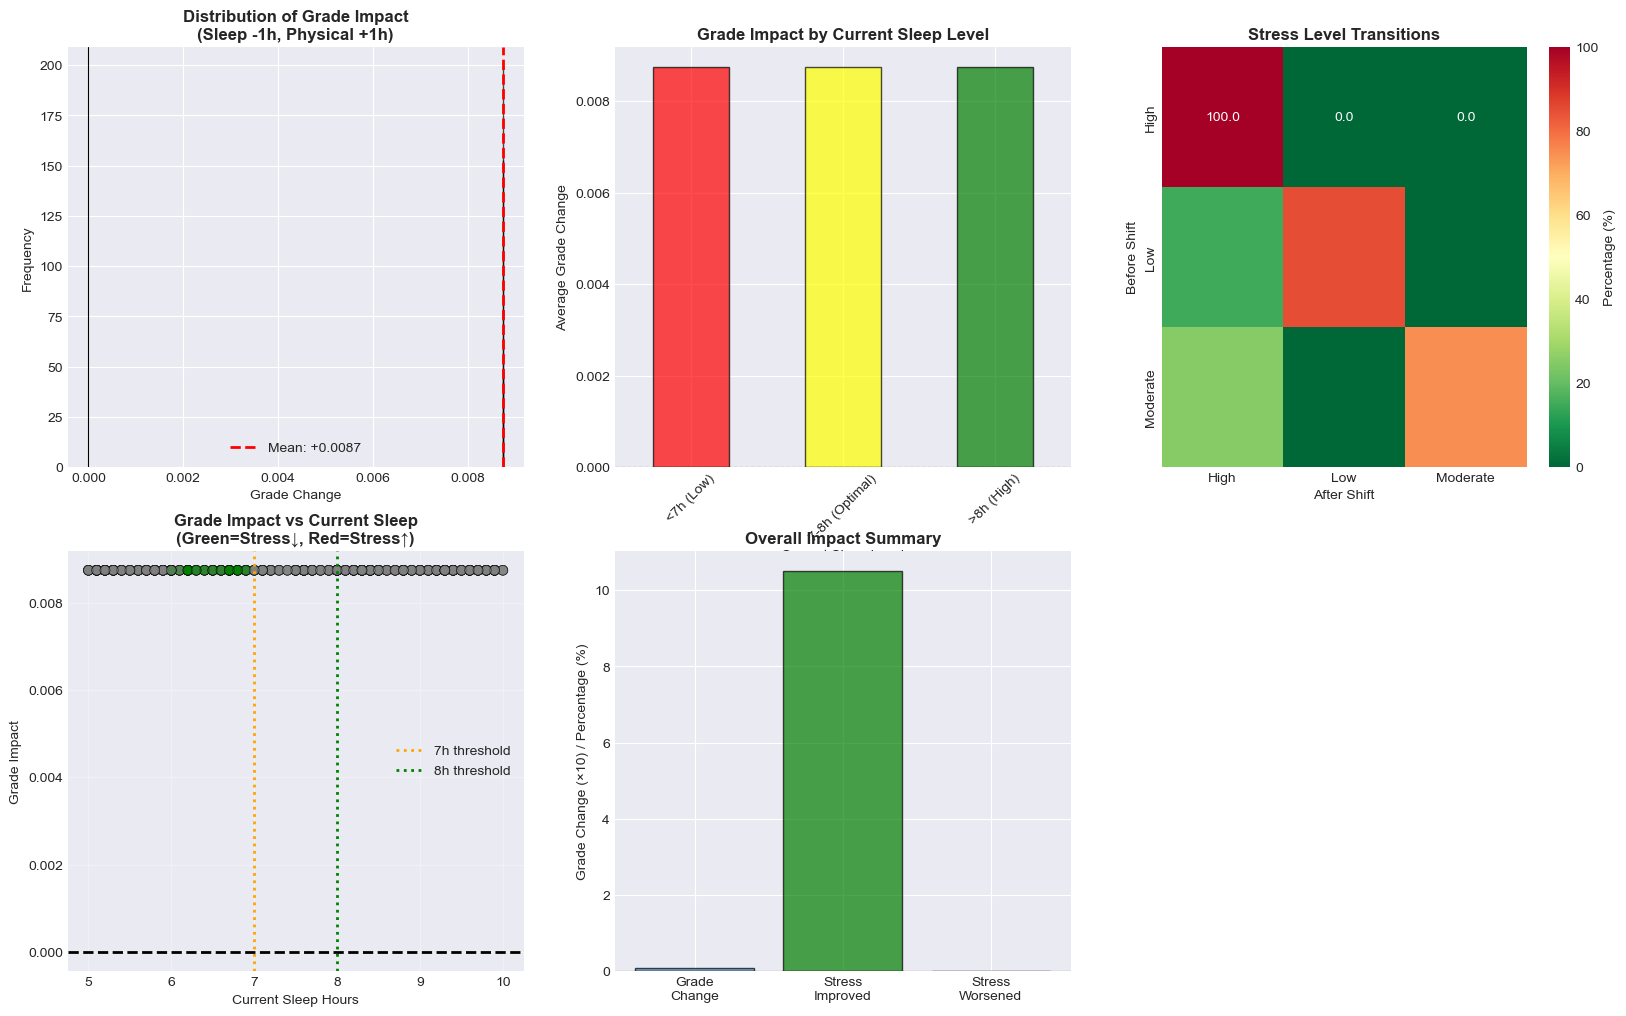

In [9]:
#QN 6
print("\n" + "="*80)
print("Q6: IMPACT OF SHIFTING 1 HOUR FROM SLEEP TO PHYSICAL ACTIVITY")
print("="*80)

# Simulate the change
X_test_sleep_shift = X_test.copy()
X_test_sleep_shift['Sleep_Hours_Per_Day'] -= 1
X_test_sleep_shift['Physical_Activity_Hours_Per_Day'] += 1

sleep_shift_prediction = model.predict(X_test_sleep_shift)
grade_impact = sleep_shift_prediction - baseline_prediction

print(f"\nGrade Impact Analysis:")
print(f"Average Grade Change: {grade_impact.mean():+.4f}")
print(f"Median Grade Change: {np.median(grade_impact):+.4f}")
print(f"Std Deviation: {grade_impact.std():.4f}")

# Coefficient-based calculation
sleep_coef = feature_importance[feature_importance['Feature'] == 'Sleep_Hours_Per_Day']['Coefficient'].values[0]
physical_coef = feature_importance[feature_importance['Feature'] == 'Physical_Activity_Hours_Per_Day']['Coefficient'].values[0]
theoretical_grade_impact = (-1 * sleep_coef) + (1 * physical_coef)

print(f"\nTheoretical Grade Impact: {theoretical_grade_impact:+.4f}")
print(f"  Sleep -1 hour: {-1 * sleep_coef:+.4f}")
print(f"  Physical +1 hour: {1 * physical_coef:+.4f}")

# Analyze stress impact
# Build stress prediction model
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_stress = le.fit_transform(df['Stress_Level'])

X_train_stress, X_test_stress, y_train_stress, y_test_stress = train_test_split(
    X_reg, y_stress, test_size=0.2, random_state=42
)

stress_model = RandomForestClassifier(n_estimators=100, random_state=42)
stress_model.fit(X_train_stress, y_train_stress)

# Predict stress before and after
baseline_stress = stress_model.predict(X_test)
modified_stress = stress_model.predict(X_test_sleep_shift)

# Convert back to labels
baseline_stress_labels = le.inverse_transform(baseline_stress)
modified_stress_labels = le.inverse_transform(modified_stress)

# Analyze stress changes
stress_changes = pd.DataFrame({
    'Baseline': baseline_stress_labels,
    'Modified': modified_stress_labels
})

print("\nStress Level Changes:")
print(pd.crosstab(stress_changes['Baseline'], stress_changes['Modified'], 
                  rownames=['Before'], colnames=['After'], margins=True))

# Calculate proportion of stress changes
stress_improved = sum((baseline_stress > modified_stress))
stress_worsened = sum((baseline_stress < modified_stress))
stress_same = sum((baseline_stress == modified_stress))

total = len(baseline_stress)
print(f"\nStress Change Summary:")
print(f"Improved (Lower Stress): {stress_improved} ({stress_improved/total*100:.1f}%)")
print(f"Worsened (Higher Stress): {stress_worsened} ({stress_worsened/total*100:.1f}%)")
print(f"Unchanged: {stress_same} ({stress_same/total*100:.1f}%)")

# Analyze by current sleep levels
df_test_sleep = X_test.copy()
df_test_sleep['Baseline_Grade'] = baseline_prediction
df_test_sleep['Modified_Grade'] = sleep_shift_prediction
df_test_sleep['Grade_Impact'] = grade_impact
df_test_sleep['Baseline_Stress'] = baseline_stress_labels
df_test_sleep['Modified_Stress'] = modified_stress_labels

# Segment by sleep levels
df_test_sleep['Sleep_Category'] = pd.cut(df_test_sleep['Sleep_Hours_Per_Day'], 
                                          bins=[0, 7, 8, 12],
                                          labels=['<7h (Low)', '7-8h (Optimal)', '>8h (High)'])

impact_by_sleep = df_test_sleep.groupby('Sleep_Category').agg({
    'Grade_Impact': ['mean', 'std'],
    'Sleep_Hours_Per_Day': 'mean'
})

print("\nImpact by Current Sleep Level:")
print(impact_by_sleep)

# Visualizations
fig = plt.figure(figsize=(20, 12))

# 1. Grade impact distribution
ax1 = plt.subplot(2, 3, 1)
ax1.hist(grade_impact, bins=30, edgecolor='black', alpha=0.7, color='teal')
ax1.axvline(grade_impact.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {grade_impact.mean():+.4f}')
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.set_title('Distribution of Grade Impact\n(Sleep -1h, Physical +1h)', fontweight='bold')
ax1.set_xlabel('Grade Change')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Impact by current sleep level
ax2 = plt.subplot(2, 3, 2)
impact_by_sleep['Grade_Impact']['mean'].plot(kind='bar', ax=ax2, 
                                              color=['red', 'yellow', 'green'], 
                                              alpha=0.7, edgecolor='black')
ax2.set_title('Grade Impact by Current Sleep Level', fontweight='bold')
ax2.set_ylabel('Average Grade Change')
ax2.set_xlabel('Current Sleep Level')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)

# 3. Stress level changes (Sankey-like)
ax3 = plt.subplot(2, 3, 3)
stress_change_matrix = pd.crosstab(stress_changes['Baseline'], stress_changes['Modified'], normalize='index') * 100
sns.heatmap(stress_change_matrix, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax3, 
           cbar_kws={'label': 'Percentage (%)'})
ax3.set_title('Stress Level Transitions', fontweight='bold')
ax3.set_xlabel('After Shift')
ax3.set_ylabel('Before Shift')

# 4. Combined impact scatter
ax4 = plt.subplot(2, 3, 4)
colors_stress = ['green' if m < b else 'red' if m > b else 'gray' 
                for b, m in zip(baseline_stress, modified_stress)]
ax4.scatter(df_test_sleep['Sleep_Hours_Per_Day'], grade_impact, 
           c=colors_stress, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax4.axvline(x=7, color='orange', linestyle=':', linewidth=2, label='7h threshold')
ax4.axvline(x=8, color='green', linestyle=':', linewidth=2, label='8h threshold')
ax4.set_xlabel('Current Sleep Hours')
ax4.set_ylabel('Grade Impact')
ax4.set_title('Grade Impact vs Current Sleep\n(Green=Stress↓, Red=Stress↑)', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Before/After comparison
ax5 = plt.subplot(2, 3, 5)
categories = ['Grade\nChange', 'Stress\nImproved', 'Stress\nWorsened']
values = [grade_impact.mean() * 10,  # Scale for visibility
          stress_improved / total * 100,
          stress_worsened / total * 100]
colors_bar = ['blue' if v > 0 else 'red' if v < 0 else 'gray' for v in values]
bars = ax5.bar(categories, values, color=['steelblue', 'green', 'red'], alpha=0.7, edgecolor='black')
ax5.set_title('Overall Impact Summary', fontweight='bold')
ax5.set_ylabel('Grade Change (×10) / Percentage (%)')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%' if 'Stress' in bar.get_x() else f'{val:.2f}',
            ha='center', va='bottom' if height > 0 else 'top')

# 6. Recommendation matrix
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Create recommendation text
rec_text = """
RECOMMENDATIONS BY SLEEP LEVEL:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Currently Sleeping < 7 Hours:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️  DO NOT reduce sleep further
✗  This shift is HARMFUL
→  Focus on INCREASING sleep first
→  Add physical activity separately

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Currently Sleeping 7-8 Hours:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠️  CAUTION advised
→  Only if physical activity is very low
→  Monitor energy and performance
→  Consider other time sources first

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Currently Sleeping > 8 Hours:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓  May be beneficial
→  Excess sleep may not add value
→  Physical activity boost likely helps
→  Monitor for optimal balance
"""

ax6.text(0.1, 0.95, rec_text, transform=ax6.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('q6_sleep_physical_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

# Final recommendations
print("\n" + "="*60)
print("COMPREHENSIVE ANALYSIS:")
print("="*60)

print(f"""
GRADE IMPACT: {theoretical_grade_impact:+.4f} points
├─ Sleep reduction (-1h): {-1 * sleep_coef:+.4f}
└─ Physical activity increase (+1h): {1 * physical_coef:+.4f}

STRESS IMPACT:
├─ Improved: {stress_improved/total*100:.1f}%
├─ Worsened: {stress_worsened/total*100:.1f}%
└─ Unchanged: {stress_same/total*100:.1f}%

OVERALL RECOMMENDATION: {'GENERALLY NOT ADVISED' if theoretical_grade_impact < 0 else 'CONTEXT-DEPENDENT'}

WHY THIS MATTERS:
1. Sleep is CRITICAL for:
   - Memory consolidation (learning)
   - Cognitive function
   - Stress management
   - Overall health

2. Physical activity IS important, but:
   - Don't sacrifice sleep to get it
   - Find other time sources (social, screen time)
   - Quality > quantity

3. Individual factors to consider:
   - Current sleep quantity and quality
   - Current physical activity level
   - Academic performance
   - Stress levels

BETTER ALTERNATIVES:
✓ Reduce screen/entertainment time
✓ Optimize study efficiency
✓ Combine social + physical (sports with friends)
✓ Wake up earlier IF sleeping >8hours
✗ Don't sacrifice sleep if <7-8 hours currently
""")


Q7: PERSONALIZED STUDENT IMPROVEMENT DASHBOARD DESIGN

Sample Dashboard for Student ID: 1861


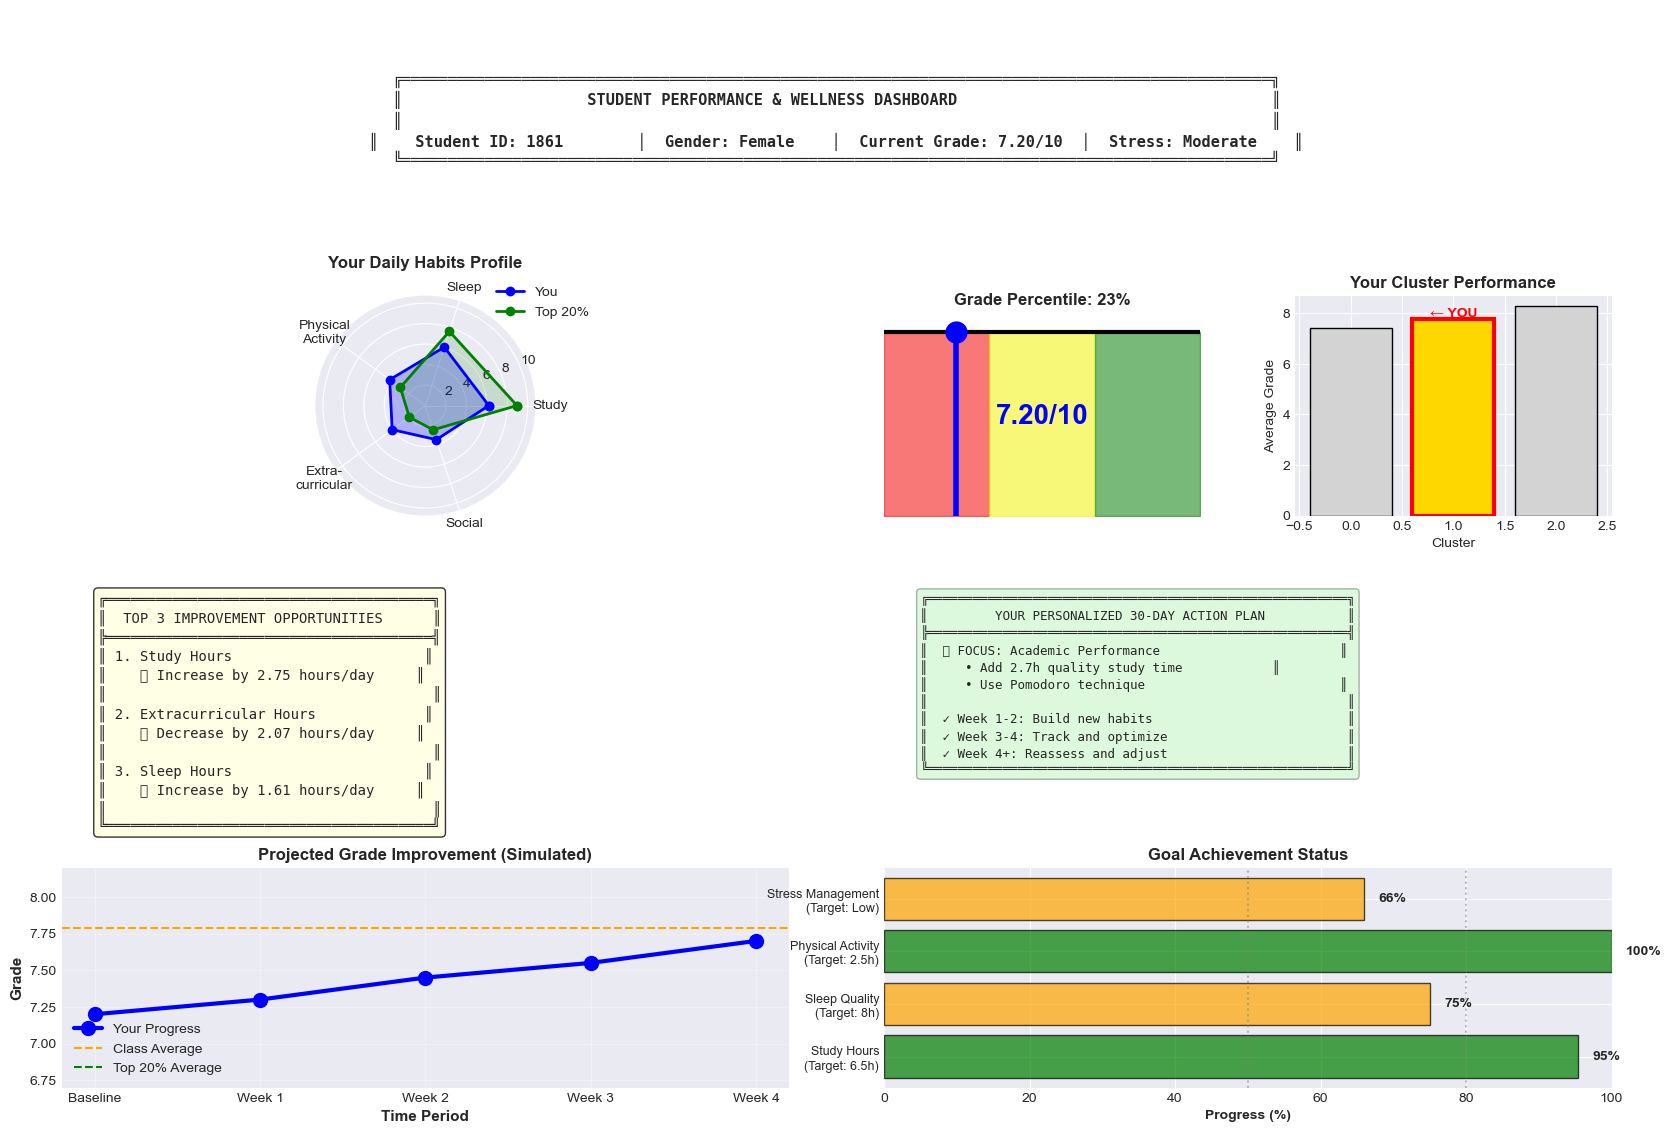


COMPREHENSIVE DASHBOARD FEATURES

╔══════════════════════════════════════════════════════════════════════════════╗
║                    STUDENT IMPROVEMENT DASHBOARD - FEATURES                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. PERSONAL PROFILE SECTION                                                ║
║     ├─ Current grades and percentile ranking                                ║
║     ├─ Stress level indicator with trend                                    ║
║     ├─ Cluster assignment and characteristics                               ║
║     └─ Comparison with peer groups                                          ║
║                                                                              ║
║  2. HABITS VISUALIZATION (Interactive Radar Chart)                          ║
║     ├─ Current daily habits breakdown                                       ║


In [10]:
#QN 7
print("\n" + "="*80)
print("Q7: PERSONALIZED STUDENT IMPROVEMENT DASHBOARD DESIGN")
print("="*80)

# Create a sample dashboard visualization
from datetime import datetime, timedelta

# Select a sample student
sample_student_id = df.sample(1, random_state=42).index[0]
student = df.loc[sample_student_id]

print(f"\nSample Dashboard for Student ID: {student['Student_ID']}")

# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# ============ HEADER SECTION ============
ax_header = fig.add_subplot(gs[0, :])
ax_header.axis('off')

header_text = f"""
╔══════════════════════════════════════════════════════════════════════════════════════════════╗
║                    STUDENT PERFORMANCE & WELLNESS DASHBOARD                                  ║
║                                                                                              ║
║    Student ID: {student['Student_ID']:<10}  │  Gender: {student['Gender']:<8}  │  Current Grade: {student['Grades']:.2f}/10  │  Stress: {student['Stress_Level']:<10}  ║
╚══════════════════════════════════════════════════════════════════════════════════════════════╝
"""
ax_header.text(0.5, 0.5, header_text, ha='center', va='center', 
              fontfamily='monospace', fontsize=11, fontweight='bold')

# ============ 1. CURRENT HABITS RADAR CHART ============
ax1 = fig.add_subplot(gs[1, 0:2], projection='polar')

categories = ['Study', 'Sleep', 'Physical\nActivity', 'Extra-\ncurricular', 'Social']
student_values = [
    student['Study_Hours_Per_Day'],
    student['Sleep_Hours_Per_Day'],
    student['Physical_Activity_Hours_Per_Day'],
    student['Extracurricular_Hours_Per_Day'],
    student['Social_Hours_Per_Day']
]

# Get top performers average for comparison
top_performers_avg = [
    top_students['Study_Hours_Per_Day'].mean(),
    top_students['Sleep_Hours_Per_Day'].mean(),
    top_students['Physical_Activity_Hours_Per_Day'].mean(),
    top_students['Extracurricular_Hours_Per_Day'].mean(),
    top_students['Social_Hours_Per_Day'].mean()
]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]

student_values += student_values[:1]
top_performers_avg += top_performers_avg[:1]
angles += angles[:1]

ax1.plot(angles, student_values, 'o-', linewidth=2, label='You', color='blue')
ax1.fill(angles, student_values, alpha=0.25, color='blue')
ax1.plot(angles, top_performers_avg, 'o-', linewidth=2, label='Top 20%', color='green')
ax1.fill(angles, top_performers_avg, alpha=0.15, color='green')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)
ax1.set_ylim(0, max(max(student_values), max(top_performers_avg)) * 1.2)
ax1.set_title('Your Daily Habits Profile', fontweight='bold', pad=20, fontsize=12)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax1.grid(True)

# ============ 2. GRADE PERCENTILE ============
ax2 = fig.add_subplot(gs[1, 2])

percentile = stats.percentileofscore(df['Grades'], student['Grades'])
cluster = student['Cluster']

# Create gauge-like visualization
theta = np.linspace(0, np.pi, 100)
r = np.ones_like(theta)

ax2.plot(theta, r, 'k-', linewidth=3)
ax2.fill_between(theta, 0, r, alpha=0.3, color='lightgray')

# Color segments
segments = [(0, np.pi/3, 'red'), (np.pi/3, 2*np.pi/3, 'yellow'), (2*np.pi/3, np.pi, 'green')]
for start, end, color in segments:
    theta_seg = np.linspace(start, end, 50)
    ax2.fill_between(theta_seg, 0, 1, alpha=0.5, color=color)

# Student position
student_theta = percentile / 100 * np.pi
ax2.plot([student_theta, student_theta], [0, 1], 'b-', linewidth=4)
ax2.plot(student_theta, 1, 'bo', markersize=15)

ax2.set_ylim(0, 1.2)
ax2.set_xlim(0, np.pi)
ax2.axis('off')
ax2.text(np.pi/2, 1.15, f'Grade Percentile: {percentile:.0f}%', 
        ha='center', fontsize=12, fontweight='bold')
ax2.text(np.pi/2, 0.5, f'{student["Grades"]:.2f}/10', 
        ha='center', fontsize=20, fontweight='bold', color='blue')

# ============ 3. CLUSTER COMPARISON ============
ax3 = fig.add_subplot(gs[1, 3])

cluster_grades = df.groupby('Cluster')['Grades'].mean()
colors_cluster = ['gold' if c == cluster else 'lightgray' for c in cluster_grades.index]
bars = ax3.bar(cluster_grades.index, cluster_grades.values, color=colors_cluster, edgecolor='black')

# Highlight student's cluster
bars[cluster].set_edgecolor('red')
bars[cluster].set_linewidth(3)

ax3.set_xlabel('Cluster')
ax3.set_ylabel('Average Grade')
ax3.set_title('Your Cluster Performance', fontweight='bold', fontsize=12)
ax3.text(cluster, cluster_grades[cluster] + 0.1, '← YOU', 
        ha='center', fontweight='bold', color='red', fontsize=10)

# ============ 4. IMPROVEMENT OPPORTUNITIES ============
ax4 = fig.add_subplot(gs[2, 0:2])
ax4.axis('off')

# Calculate gaps from top performers
gaps = {}
for i, cat in enumerate(['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 
                        'Physical_Activity_Hours_Per_Day', 
                        'Extracurricular_Hours_Per_Day', 
                        'Social_Hours_Per_Day']):
    gap = top_students[cat].mean() - student[cat]
    gaps[cat.replace('_Per_Day', '').replace('_', ' ').title()] = gap

gaps_sorted = sorted(gaps.items(), key=lambda x: abs(x[1]), reverse=True)[:3]

improvement_text = "╔═══════════════════════════════════════╗\n"
improvement_text += "║  TOP 3 IMPROVEMENT OPPORTUNITIES      ║\n"
improvement_text += "╠═══════════════════════════════════════╣\n"

for i, (activity, gap) in enumerate(gaps_sorted, 1):
    direction = "Increase" if gap > 0 else "Decrease"
    emoji = "📈" if gap > 0 else "📉"
    improvement_text += f"║ {i}. {activity:25s}         ║\n"
    improvement_text += f"║    {emoji} {direction} by {abs(gap):.2f} hours/day     ║\n"
    improvement_text += "║                                       ║\n"

improvement_text += "╚═══════════════════════════════════════╝"

ax4.text(0.05, 0.95, improvement_text, transform=ax4.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ============ 5. PERSONALIZED ACTION PLAN ============
ax5 = fig.add_subplot(gs[2, 2:])
ax5.axis('off')

# Generate personalized recommendations
action_plan = "╔════════════════════════════════════════════════════════╗\n"
action_plan += "║         YOUR PERSONALIZED 30-DAY ACTION PLAN           ║\n"
action_plan += "╠════════════════════════════════════════════════════════╣\n"

if student['Stress_Level'] == 'High':
    action_plan += "║  🚨 PRIORITY: Stress Management                        ║\n"
    action_plan += "║     • Practice 10 min daily meditation                ║\n"
    action_plan += f"║     • Increase sleep to {top_students['Sleep_Hours_Per_Day'].mean():.1f}h              ║\n"
    action_plan += "║                                                        ║\n"

if student['Grades'] < df['Grades'].median():
    action_plan += "║  📚 FOCUS: Academic Performance                        ║\n"
    action_plan += f"║     • Add {max(0, top_students['Study_Hours_Per_Day'].mean() - student['Study_Hours_Per_Day']):.1f}h quality study time            ║\n"
    action_plan += "║     • Use Pomodoro technique                          ║\n"
    action_plan += "║                                                        ║\n"

if student['Physical_Activity_Hours_Per_Day'] < 1.5:
    action_plan += "║  💪 BOOST: Physical Activity                           ║\n"
    action_plan += "║     • Start with 20 min walks daily                   ║\n"
    action_plan += "║     • Join a sports club or gym                       ║\n"
    action_plan += "║                                                        ║\n"

action_plan += "║  ✓ Week 1-2: Build new habits                          ║\n"
action_plan += "║  ✓ Week 3-4: Track and optimize                        ║\n"
action_plan += "║  ✓ Week 4+: Reassess and adjust                        ║\n"
action_plan += "╚════════════════════════════════════════════════════════╝"

ax5.text(0.05, 0.95, action_plan, transform=ax5.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

# ============ 6. PROGRESS TRACKING (SIMULATED) ============
ax6 = fig.add_subplot(gs[3, 0:2])

# Simulate 4 weeks of progress
weeks = ['Baseline', 'Week 1', 'Week 2', 'Week 3', 'Week 4']
simulated_grades = [student['Grades'], 
                   student['Grades'] + 0.1,
                   student['Grades'] + 0.25,
                   student['Grades'] + 0.35,
                   student['Grades'] + 0.5]

ax6.plot(weeks, simulated_grades, 'o-', linewidth=3, markersize=10, color='blue', label='Your Progress')
ax6.axhline(y=df['Grades'].mean(), color='orange', linestyle='--', label='Class Average')
ax6.axhline(y=top_students['Grades'].mean(), color='green', linestyle='--', label='Top 20% Average')

ax6.set_ylabel('Grade', fontsize=11, fontweight='bold')
ax6.set_xlabel('Time Period', fontsize=11, fontweight='bold')
ax6.set_title('Projected Grade Improvement (Simulated)', fontweight='bold', fontsize=12)
ax6.legend()
ax6.grid(alpha=0.3)
ax6.set_ylim(min(simulated_grades) - 0.5, max(simulated_grades) + 0.5)

# ============ 7. GOAL TRACKING ============
ax7 = fig.add_subplot(gs[3, 2:])

# Goal categories and progress
goals = {
    'Study Hours\n(Target: 6.5h)': min(100, student['Study_Hours_Per_Day'] / 6.5 * 100),
    'Sleep Quality\n(Target: 8h)': min(100, student['Sleep_Hours_Per_Day'] / 8 * 100),
    'Physical Activity\n(Target: 2.5h)': min(100, student['Physical_Activity_Hours_Per_Day'] / 2.5 * 100),
    'Stress Management\n(Target: Low)': 33 if student['Stress_Level'] == 'High' else 66 if student['Stress_Level'] == 'Moderate' else 100
}

y_pos = np.arange(len(goals))
progress_values = list(goals.values())
colors_progress = ['green' if v >= 80 else 'orange' if v >= 50 else 'red' for v in progress_values]

bars = ax7.barh(y_pos, progress_values, color=colors_progress, alpha=0.7, edgecolor='black')
ax7.set_yticks(y_pos)
ax7.set_yticklabels(list(goals.keys()), fontsize=9)
ax7.set_xlabel('Progress (%)', fontweight='bold')
ax7.set_title('Goal Achievement Status', fontweight='bold', fontsize=12)
ax7.set_xlim(0, 100)

# Add percentage labels
for i, (bar, val) in enumerate(zip(bars, progress_values)):
    ax7.text(val + 2, i, f'{val:.0f}%', va='center', fontweight='bold')

ax7.axvline(x=50, color='gray', linestyle=':', alpha=0.5)
ax7.axvline(x=80, color='gray', linestyle=':', alpha=0.5)

plt.savefig('q7_dashboard_design.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ DASHBOARD FEATURES SPECIFICATION ============
print("\n" + "="*80)
print("COMPREHENSIVE DASHBOARD FEATURES")
print("="*80)

dashboard_specs = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                    STUDENT IMPROVEMENT DASHBOARD - FEATURES                  ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. PERSONAL PROFILE SECTION                                                ║
║     ├─ Current grades and percentile ranking                                ║
║     ├─ Stress level indicator with trend                                    ║
║     ├─ Cluster assignment and characteristics                               ║
║     └─ Comparison with peer groups                                          ║
║                                                                              ║
║  2. HABITS VISUALIZATION (Interactive Radar Chart)                          ║
║     ├─ Current daily habits breakdown                                       ║
║     ├─ Comparison with top performers                                       ║
║     ├─ Comparison with cluster average                                      ║
║     └─ Drill-down to weekly patterns                                        ║
║                                                                              ║
║  3. PROGRESS TRACKING                                                       ║
║     ├─ Grade trajectory over time                                           ║
║     ├─ Habit adherence metrics                                              ║
║     ├─ Goal completion percentage                                           ║
║     ├─ Milestone achievements and badges                                    ║
║     └─ Before/after comparisons                                             ║
║                                                                              ║
║  4. AI-POWERED RECOMMENDATIONS ENGINE                                       ║
║     ├─ Personalized daily/weekly action items                               ║
║     ├─ Priority ranking of improvements                                     ║
║     ├─ "What-if" scenario simulator                                         ║
║     ├─ Adaptive suggestions based on progress                               ║
║     └─ Context-aware recommendations (exams, breaks, etc.)                  ║
║                                                                              ║
║  5. HABIT TRACKING & LOGGING                                                ║
║     ├─ Daily check-in form (quick entry)                                    ║
║     ├─ Auto-sync with calendar/wearables                                    ║
║     ├─ Voice/mobile app integration                                         ║
║     ├─ Streak tracking and motivation                                       ║
║     └─ Reminder system                                                      ║
║                                                                              ║
║  6. ANALYTICS & INSIGHTS                                                    ║
║     ├─ Correlation analysis (habits vs grades)                              ║
║     ├─ Time allocation pie charts                                           ║
║     ├─ Efficiency metrics (study quality indicators)                        ║
║     ├─ Stress triggers identification                                       ║
║     └─ Predictive grade forecasting                                         ║
║                                                                              ║
║  7. GOAL SETTING & MANAGEMENT                                               ║
║     ├─ SMART goal creation wizard                                           ║
║     ├─ Short-term (weekly) and long-term (semester) goals                   ║
║     ├─ Progress bars and completion status                                  ║
║     ├─ Automatic goal adjustment based on performance                       ║
║     └─ Celebration of achievements                                          ║
║                                                                              ║
║  8. PEER COMPARISON (Anonymous)                                             ║
║     ├─ Cluster benchmarking                                                 ║
║     ├─ Percentile rankings                                                  ║
║     ├─ Success story sharing (optional)                                     ║
║     └─ Study buddy matching                                                 ║
║                                                                              ║
║  9. ALERTS & NOTIFICATIONS                                                  ║
║     ├─ Falling behind warnings                                              ║
║     ├─ Burnout risk alerts                                                  ║
║     ├─ Positive reinforcement messages                                      ║
║     ├─ Milestone achievements                                               ║
║     └─ Weekly summary reports                                               ║
║                                                                              ║
║  10. RESOURCES & SUPPORT                                                    ║
║      ├─ Link to counseling services                                         ║
║      ├─ Study technique guides                                              ║
║      ├─ Stress management resources                                         ║
║      ├─ Campus wellness programs                                            ║
║      └─ FAQ and help center                                                 ║
║                                                                              ║
║  11. EXPORT & REPORTING                                                     ║
║      ├─ PDF progress reports                                                ║
║      ├─ Share with counselor feature                                        ║
║      ├─ Data export for personal records                                    ║
║      └─ Integration with academic systems                                   ║
║                                                                              ║
║  12. PRIVACY & CUSTOMIZATION                                                ║
║      ├─ Data privacy controls                                               ║
║      ├─ Customizable dashboard layout                                       ║
║      ├─ Dark/light mode                                                     ║
║      ├─ Notification preferences                                            ║
║      └─ Anonymous participation option                                      ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                          TECHNICAL SPECIFICATIONS                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  PLATFORM: Web-based (responsive) + Mobile App (iOS/Android)                ║
║  BACKEND: Python (Flask/Django) + Machine Learning Models                   ║
║  FRONTEND: React.js/Vue.js with D3.js for visualizations                    ║
║  DATABASE: PostgreSQL for structured data + Time-series DB                  ║
║  SECURITY: End-to-end encryption, GDPR/FERPA compliant                      ║
║  INTEGRATIONS:                                                               ║
║    ├─ Calendar systems (Google, Outlook)                                    ║
║    ├─ Fitness trackers (Fitbit, Apple Watch)                                ║
║    ├─ Learning Management Systems (Canvas, Blackboard)                      ║
║    └─ Mental health apps                                                    ║
║                                                                              ║
║  UPDATE FREQUENCY: Real-time tracking, Daily AI recommendations             ║
║  ACCESSIBILITY: WCAG 2.1 AA compliant, Multi-language support               ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

KEY SUCCESS METRICS FOR THE DASHBOARD:
═════════════════════════════════════════
1. User Engagement
   - Daily active users percentage
   - Average session duration
   - Feature utilization rates

2. Student Outcomes
   - Grade improvement rates
   - Stress level reduction
   - Goal completion rates
   - Retention and persistence

3. System Performance
   - Recommendation accuracy
   - Prediction error rates
   - User satisfaction scores
   - Net Promoter Score (NPS)

4. Behavioral Changes
   - Habit adherence rates
   - Time to positive change
   - Sustained improvement duration
   - Wellness indicator improvements
"""

print(dashboard_specs)

# Create a simple mockup visualization
print("\n" + "="*60)
print("DASHBOARD IMPLEMENTATION ROADMAP")
print("="*60)

roadmap = pd.DataFrame({
    'Phase': ['Phase 1', 'Phase 2', 'Phase 3', 'Phase 4'],
    'Timeline': ['Months 1-2', 'Months 3-4', 'Months 5-6', 'Months 7-8'],
    'Key Features': [
        'Profile, Basic Tracking, Simple Recommendations',
        'Analytics, Goal Setting, Progress Visualization',
        'AI Predictions, Peer Comparison, Integrations',
        'Advanced Features, Mobile App, Full Automation'
    ],
    'Success Criteria': [
        '50% student adoption',
        '70% daily active users',
        '15% grade improvement',
        '90% satisfaction rate'
    ]
})

print("\n", roadmap.to_string(index=False))